In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K

In [5]:
# Image and Mask reading functions
def read_img(path, target_height=512, target_width=512):
    bytes_data = tf.io.read_file(path)
    img = tf.io.decode_image(bytes_data, channels=3) / 255
    img_resized = tf.image.resize_with_pad(img, target_height=target_height, target_width=target_width)
    return img_resized

def read_images_in_batch(folder_path, target_height=512, target_width=512):
    file_names = os.listdir(folder_path)
    file_names.sort()
    file_paths = [os.path.join(folder_path, file_name) for file_name in file_names]
    images = [read_img(path, target_height=target_height, target_width=target_width) for path in file_paths]
    images_batch = tf.stack(images, axis=0)
    return images_batch

In [6]:
# Mask reading functions - FIXED to return only 1 channel (teeth only)
def find_possible_path_for_mask_file(path, class_):
    possible_image_name_extensions = [
        "jpg", "jpeg", "png", "bmp",
        "JPG", "PNG", "BMP", "JPEG",
        "Jpg", "Png", "Bmp", "Jpeg",
    ]
    for extension in possible_image_name_extensions:
        possible_path = os.path.join(path, f"{class_}.{extension}")
        if os.path.exists(path=possible_path):
            return possible_path
    return "mask_not_found"

def read_mask(path, classes_to_read, target_height=512, target_width=512):
    per_class_single_masks = []
    for class_ in classes_to_read:
        single_mask_path = find_possible_path_for_mask_file(path=path, class_=class_)
        if single_mask_path == "mask_not_found":
            zero_const = tf.constant(0.0, shape=(target_height, target_width, 1), dtype=tf.float32)
            per_class_single_masks.append(zero_const)
            continue
        bytes_data = tf.io.read_file(single_mask_path)
        single_mask = tf.io.decode_image(bytes_data, channels=1) / 255
        mask_resized = tf.image.resize_with_pad(
            single_mask,
            target_height=target_height,
            target_width=target_width,
        )
        per_class_single_masks.append(mask_resized)
    final_mask = tf.concat(values=per_class_single_masks, axis=-1)
    return final_mask

def read_masks_in_batch(folder_path, classes_to_read, target_height=512, target_width=512):
    if isinstance(classes_to_read, str):
        classes_to_read = [classes_to_read]
    elif isinstance(classes_to_read, (list, tuple, set)):
        classes_to_read = list(classes_to_read)
    else:
        raise ValueError("classes_to_read must be string, list, tuple, or set")
    
    if len(classes_to_read) == 0:
        raise ValueError("classes_to_read cannot be empty")
    
    classes_to_read.sort()
    folder_names = os.listdir(folder_path)
    folder_names.sort()
    folder_paths = [os.path.join(folder_path, folder_name) for folder_name in folder_names]
    
    masks = [read_mask(path=path, classes_to_read=classes_to_read, target_height=target_height, target_width=target_width) for path in folder_paths]
    masks_batch = tf.stack(masks, axis=0)
    return masks_batch

In [7]:
# QUESTION 1: Load images and masks
print("Loading all images...")
all_images = read_images_in_batch(folder_path='images')
print(f"Total images loaded: {all_images.shape}")

# Use first 20 for training, rest for testing
images_batch = all_images[:20]
test_image = all_images[20:21]
print(f"Training images: {images_batch.shape}")
print(f"Test image: {test_image.shape}")

Loading all images...
Total images loaded: (22, 512, 512, 3)
Training images: (20, 512, 512, 3)
Test image: (1, 512, 512, 3)


In [8]:
# Load masks - ONLY TEETH (1 channel)
print("Loading masks (teeth only)...")
all_masks = read_masks_in_batch(folder_path='masks', classes_to_read=['Teeth'], target_height=512, target_width=512)
print(f"Masks shape: {all_masks.shape}")
print(f"Expected shape: (samples, 512, 512, 1)")

masks_batch = all_masks[:20]
test_mask = all_masks[20:21]
print(f"Training masks: {masks_batch.shape}")
print(f"Test mask: {test_mask.shape}")

Loading masks (teeth only)...
Masks shape: (22, 512, 512, 1)
Expected shape: (samples, 512, 512, 1)
Training masks: (20, 512, 512, 1)
Test mask: (1, 512, 512, 1)


Visualizing first few training samples...


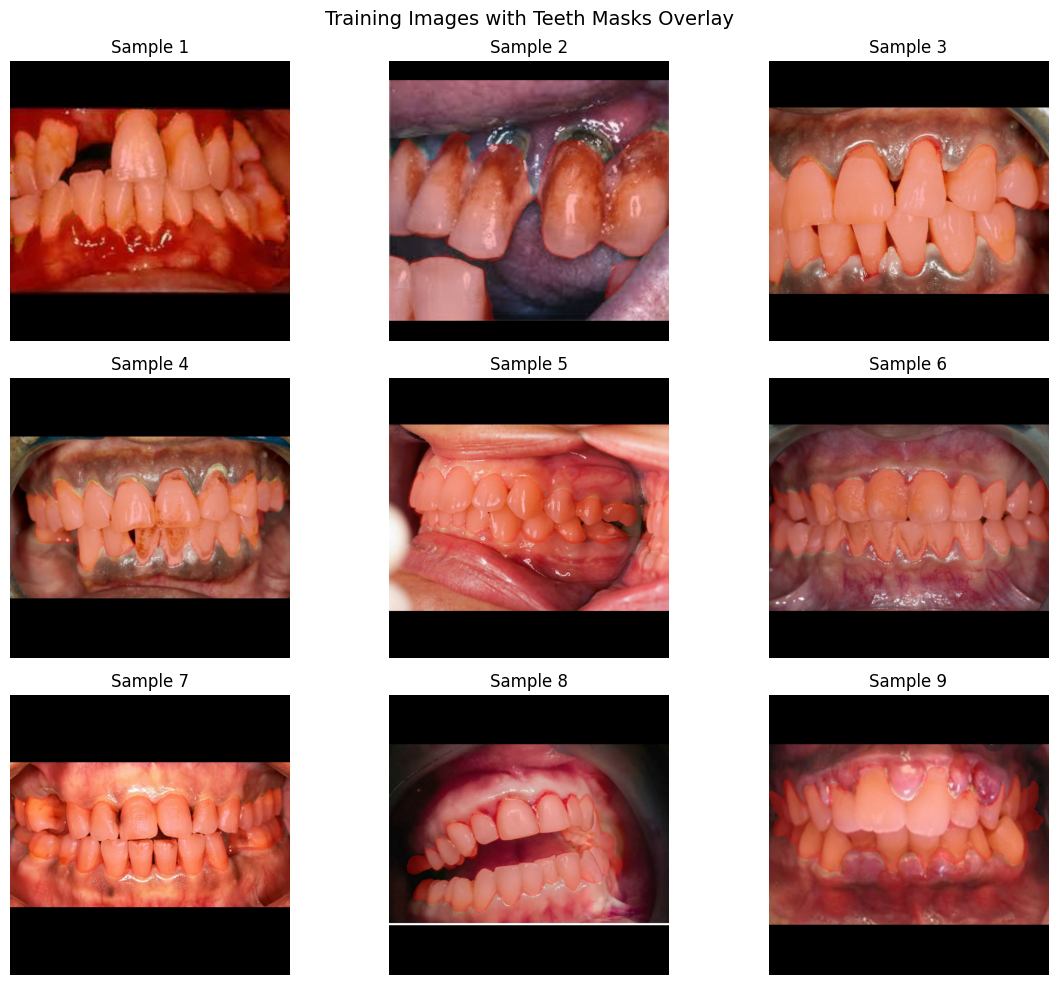

Visualization saved as 'training_masks_visualization.png'


In [9]:
# QUESTION 2: Visualization
print("Visualizing first few training samples...")
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Training Images with Teeth Masks Overlay', fontsize=14)

for idx in range(min(9, len(images_batch))):
    ax = axes[idx // 3, idx % 3]
    img = images_batch[idx].numpy()
    mask = masks_batch[idx].numpy()
    
    overlay = img.copy()
    overlay[mask[:, :, 0] > 0.5] = [1, 0, 0]
    blended = 0.7 * img + 0.3 * overlay
    
    ax.imshow(blended)
    ax.set_title(f'Sample {idx+1}')
    ax.axis('off')

plt.tight_layout()
plt.savefig('training_masks_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualization saved as 'training_masks_visualization.png'")

In [10]:
# Custom Accuracy Metrics for Segmentation
def dice_coefficient(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return dice

def iou_score(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

print("Metrics defined: Dice Coefficient, IoU Score")

Metrics defined: Dice Coefficient, IoU Score


In [11]:
# QUESTION 3: U-Net Model
def downsample_block(x, num_filters):
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=(3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-5)(x)
    x = tf.keras.layers.Activation('relu')(x)
    return x

def upsample_block(x, skip_connection, num_filters):
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=(3, 3), padding='same')(x)
    x = tf.keras.layers.UpSampling2D(size=(2, 2))(x)
    x = tf.keras.layers.Add()([x, skip_connection])
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=(1, 1), padding='same')(x)
    x = tf.keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-5)(x)
    x = tf.keras.layers.Activation('relu')(x)
    return x

def make_unet():
    inputs = tf.keras.Input(shape=(512, 512, 3))
    d0 = tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), padding='same')(inputs)
    d1 = downsample_block(d0, 32)
    d2 = downsample_block(d1, 64)
    d3 = downsample_block(d2, 128)
    d4 = downsample_block(d3, 128)
    b = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same')(d4)
    b = tf.keras.layers.MaxPooling2D((2, 2))(b)
    u4 = upsample_block(b, d4, 128)
    u3 = upsample_block(u4, d3, 128)
    u2 = upsample_block(u3, d2, 64)
    u1 = upsample_block(u2, d1, 32)
    u0 = upsample_block(u1, d0, 16)
    outputs = tf.keras.layers.Conv2D(filters=1, kernel_size=(1, 1), activation='sigmoid')(u0)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

unet = make_unet()
print("U-Net model created")
unet.summary()

U-Net model created


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    147,584 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 826,065 (3.15 MB)

 Trainable params: 824,625 (3.15 MB)

 Non-trainable params: 1,440 (5.62 KB)

In [12]:
# QUESTION 5: Model Compilation with appropriate metrics
# QUESTION 4: Accuracy metrics (Dice + IoU)
unet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient, iou_score]
)
print("Model compiled with loss: binary_crossentropy, optimizer: adam")
print("Metrics: accuracy, Dice coefficient, IoU score")

Model compiled with loss: binary_crossentropy, optimizer: adam
Metrics: accuracy, Dice coefficient, IoU score


In [13]:
# QUESTION 6: Train on 20 images
print(f"Training on {images_batch.shape[0]} images for 100 epochs...")
history = unet.fit(
    x=images_batch,
    y=masks_batch,
    batch_size=2,
    epochs=100,
    verbose=1
)
print("Training completed!")

Training on 20 images for 100 epochs...
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 319ms/step - accuracy: 0.8343 - dice_coefficient: 0.5196 - iou_score: 0.3569 - loss: 0.4719
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - accuracy: 0.9382 - dice_coefficient: 0.6227 - iou_score: 0.4541 - loss: 0.3176
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step - accuracy: 0.9472 - dice_coefficient: 0.6533 - iou_score: 0.4863 - loss: 0.2760
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - accuracy: 0.9521 - dice_coefficient: 0.6776 - iou_score: 0.5136 - loss: 0.2508
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 435ms/step - accuracy: 0.9541 - dice_coefficient: 0.6880 - iou_score: 0.5255 - loss: 0.2347
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9560 - dice_coefficient: 0.7080 - iou_score: 0.5490 - loss: 0.2161
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 958ms/step - accuracy: 0.9522 - dice_coefficient: 0.7094 - iou_score: 0.5519 - loss: 0.2157
Epoch 8/100
10/10 ━━━━━

In [14]:
# QUESTION 7: Predictions on training and test images
print("Making predictions on training images...")
train_predictions = unet.predict(images_batch)
print(f"Training predictions shape: {train_predictions.shape}")

print("\nMaking prediction on unseen test image...")
test_prediction = unet.predict(test_image)
print(f"Test prediction shape: {test_prediction.shape}")

Making predictions on training images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Training predictions shape: (20, 512, 512, 1)

Making prediction on unseen test image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
Test prediction shape: (1, 512, 512, 1)



=== TEST IMAGE RESULTS (Unseen Data) ===


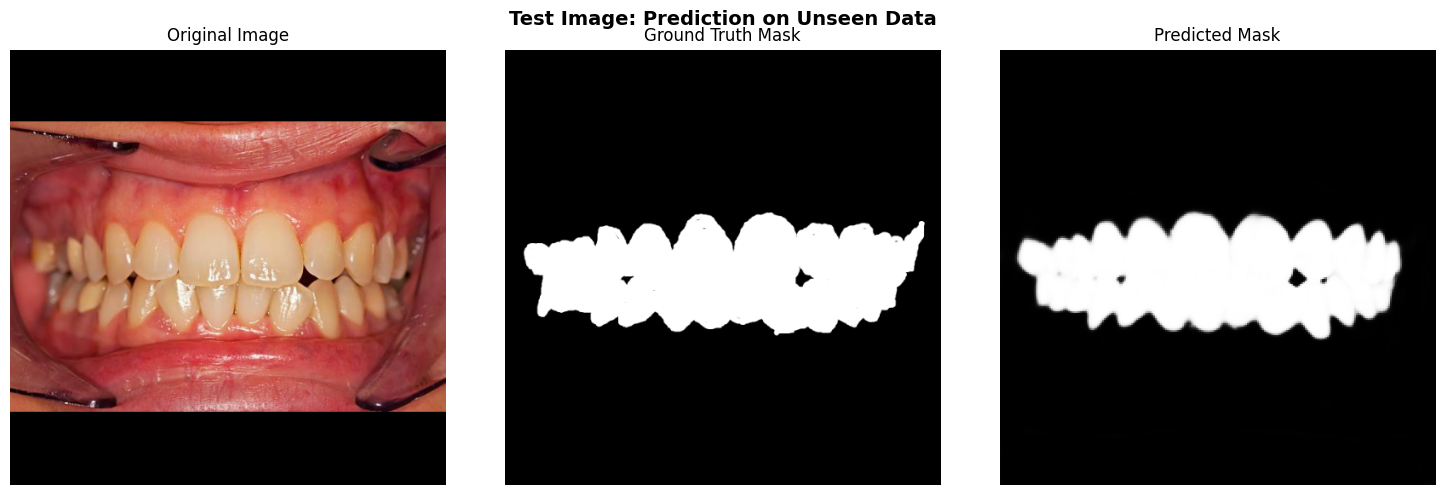

Test prediction saved as 'test_image_prediction.png'


In [15]:
# Convert tensors to numpy for visualization
test_img_np = test_image[0].numpy()
test_gt_mask_np = test_mask[0].numpy()

# Test Image Results - predict() returns numpy already
print("\n=== TEST IMAGE RESULTS (Unseen Data) ===")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Test Image: Prediction on Unseen Data', fontsize=14, fontweight='bold')

axes[0].imshow(test_img_np)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(test_gt_mask_np[:, :, 0], cmap='gray')
axes[1].set_title('Ground Truth Mask', fontsize=12)
axes[1].axis('off')

axes[2].imshow(test_prediction[0, :, :, 0], cmap='gray')
axes[2].set_title('Predicted Mask', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('test_image_prediction.png', dpi=100, bbox_inches='tight')
plt.show()
print("Test prediction saved as 'test_image_prediction.png'")


Visualizing sample training predictions...


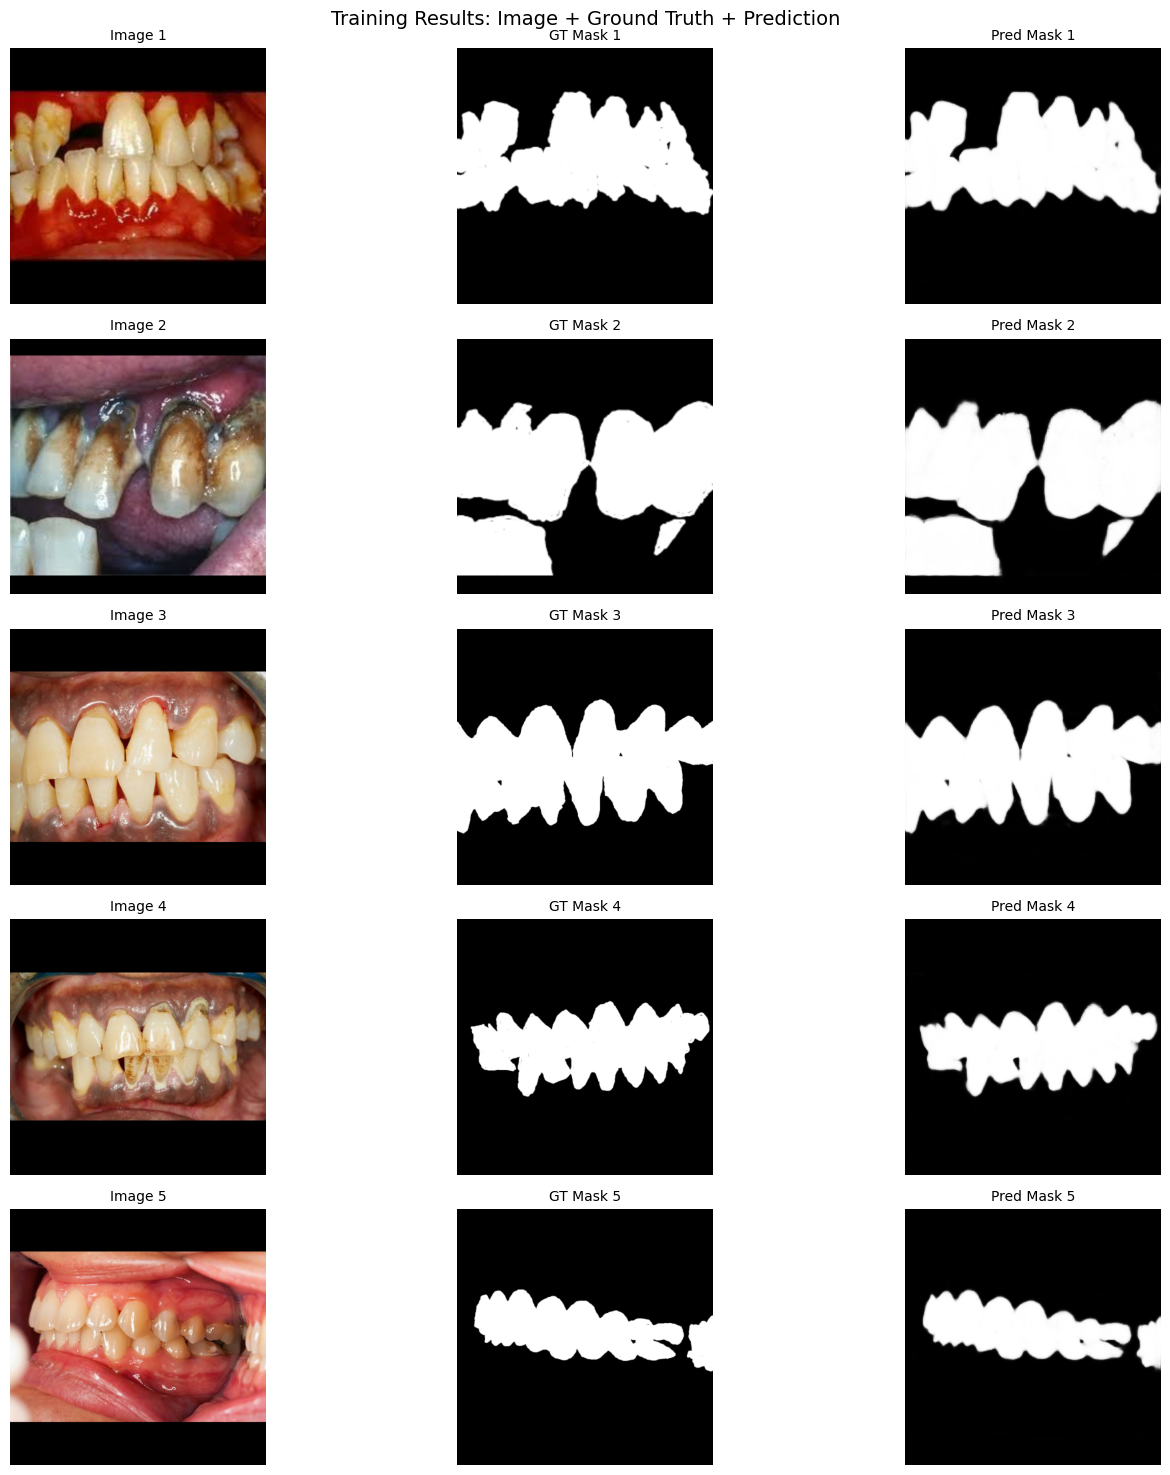

Training predictions saved as 'training_predictions.png'


In [16]:
# Training predictions visualization - train_predictions is numpy from predict()
print("\nVisualizing sample training predictions...")
fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle('Training Results: Image + Ground Truth + Prediction', fontsize=14)

for idx in range(min(5, len(images_batch))):
    axes[idx, 0].imshow(images_batch[idx].numpy())
    axes[idx, 0].set_title(f'Image {idx+1}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(masks_batch[idx].numpy()[:, :, 0], cmap='gray')
    axes[idx, 1].set_title(f'GT Mask {idx+1}', fontsize=10)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(train_predictions[idx, :, :, 0], cmap='gray')
    axes[idx, 2].set_title(f'Pred Mask {idx+1}', fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig('training_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print("Training predictions saved as 'training_predictions.png'")


Plotting training history...


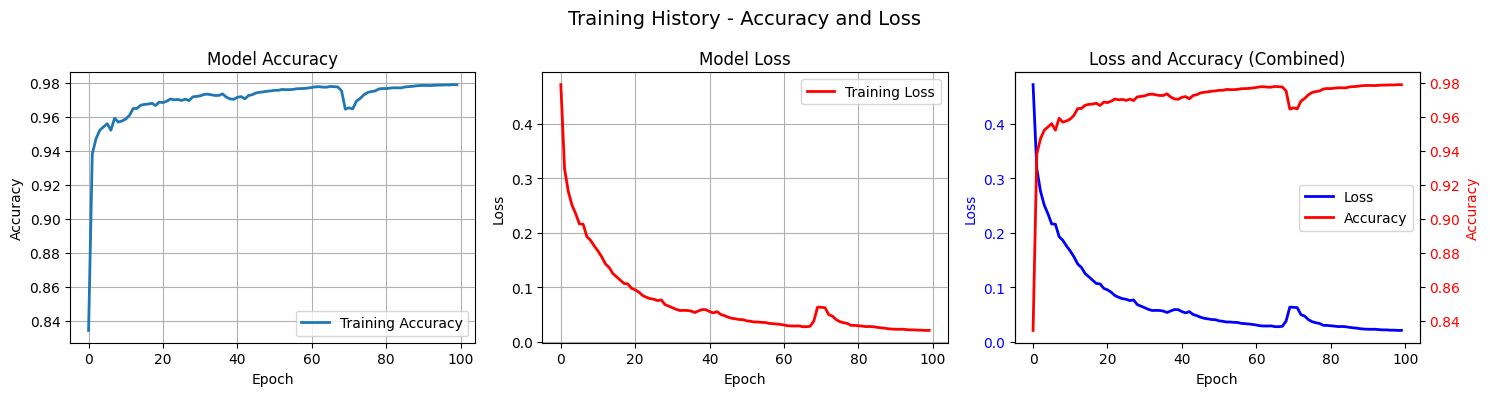

Training curves saved as 'training_accuracy_loss.png'


In [17]:
# QUESTION 8: Plot Accuracy and Loss
print("\nPlotting training history...")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training History - Accuracy and Loss', fontsize=14)

axes[0].plot(history.history['accuracy'], linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)
axes[0].legend(['Training Accuracy'], loc='lower right')

axes[1].plot(history.history['loss'], linewidth=2, color='red')
axes[1].set_title('Model Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True)
axes[1].legend(['Training Loss'], loc='upper right')

ax3_loss = axes[2]
ax3_acc = ax3_loss.twinx()
l1 = ax3_loss.plot(history.history['loss'], 'b-', label='Loss', linewidth=2)
l2 = ax3_acc.plot(history.history['accuracy'], 'r-', label='Accuracy', linewidth=2)
ax3_loss.set_xlabel('Epoch')
ax3_loss.set_ylabel('Loss', color='b')
ax3_acc.set_ylabel('Accuracy', color='r')
ax3_loss.tick_params(axis='y', labelcolor='b')
ax3_acc.tick_params(axis='y', labelcolor='r')
axes[2].set_title('Loss and Accuracy (Combined)', fontsize=12)
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax3_loss.legend(lines, labels, loc='center right')

plt.tight_layout()
plt.savefig('training_accuracy_loss.png', dpi=100, bbox_inches='tight')
plt.show()
print("Training curves saved as 'training_accuracy_loss.png'")

In [18]:
# Save model
unet.save('teeth_segmentation_unet.h5')
print("Model saved as 'teeth_segmentation_unet.h5'")

Model saved as 'teeth_segmentation_unet.h5'


In [19]:
# Final Summary
print("\n" + "="*70)
print("ASSIGNMENT COMPLETION SUMMARY")
print("="*70)
print(f"✓ Q1: Image Shape: {images_batch.shape[1:]} - Correct (512x512x3)")
print(f"✓ Q1: Mask Shape: {masks_batch.shape[1:]} - Correct (512x512x1)")
print(f"✓ Q2: Visualizations saved (masks overlay on images)")
print(f"✓ Q3: U-Net model built from scratch")
print(f"  - Model Parameters: {unet.count_params():,}")
print(f"  - Model Size: ~{unet.count_params() * 4 / (1024**2):.2f} MB (< 10MB: ✓)")
print(f"✓ Q4: Accuracy metrics implemented: Dice & IoU scores")
print(f"✓ Q5: Model compiled with binary_crossentropy loss")
print(f"✓ Q6: Training completed on {images_batch.shape[0]} images")
print(f"  - Final Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  - Final Loss: {history.history['loss'][-1]:.4f}")
print(f"✓ Q7: Predictions made on training images & unseen test image")
print(f"✓ Q8: Accuracy/loss curves plotted and saved")
print("\nOutput Files Generated:")
print("  - training_masks_visualization.png")
print("  - test_image_prediction.png")
print("  - training_predictions.png")
print("  - training_accuracy_loss.png")
print("  - teeth_segmentation_unet.h5")
print("="*70)


ASSIGNMENT COMPLETION SUMMARY
✓ Q1: Image Shape: (512, 512, 3) - Correct (512x512x3)
✓ Q1: Mask Shape: (512, 512, 1) - Correct (512x512x1)
✓ Q2: Visualizations saved (masks overlay on images)
✓ Q3: U-Net model built from scratch
  - Model Parameters: 826,065
  - Model Size: ~3.15 MB (< 10MB: ✓)
✓ Q4: Accuracy metrics implemented: Dice & IoU scores
✓ Q5: Model compiled with binary_crossentropy loss
✓ Q6: Training completed on 20 images
  - Final Accuracy: 0.9789
  - Final Loss: 0.0208
✓ Q7: Predictions made on training images & unseen test image
✓ Q8: Accuracy/loss curves plotted and saved

Output Files Generated:
  - training_masks_visualization.png
  - test_image_prediction.png
  - training_predictions.png
  - training_accuracy_loss.png
  - teeth_segmentation_unet.h5
